In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo



features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd


df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

In [3]:
from itertools import product
import numpy as np
from training_info import TrainingInfo

w_signal_ratio_dict = {}
signal_ratios = [0.01]
experiment_name = "base_fvt_training_ensemble"
dataset_seeds = range(1)

for signal_ratio, dataset_seed in product(signal_ratios, dataset_seeds):
    hparams_filter = {
        "experiment_name": experiment_name,
        "dataset": lambda x: (
            x["signal_ratio"] == signal_ratio
            and x["seed"] == dataset_seed
            and x["n_3b"] == 1_000_000
        ),
    }
    hashes, hparams = TrainingInfo.find(hparams_filter, return_hparams=True)
    # sort hashes by signal_ratio and seed
    to_sort = [hp["train_seed"] for hp in hparams]
    idx = np.arange(len(hashes))
    hashes = [hashes[i] for i, _ in sorted(zip(idx, to_sort), key=lambda x: x[1])]
    
    base_fvt_info = TrainingInfo.load(hashes[0])
    msamples = MotherSamples.load(base_fvt_info.ms_hash)
    tst_scdinfo = msamples.scdinfo[~base_fvt_info.ms_idx]
    df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
    events_tst = EventsData.from_dataframe(df_tst, features)
    
    base_fvt_scores = []
    for hash in hashes:
        base_fvt_info = TrainingInfo.load(hash)
        base_fvt_model = base_fvt_info.load_trained_model("best")
        base_fvt_model: FvTClassifier
        base_fvt_model.eval()
        base_fvt_model.to("cuda")
        
        base_fvt_score = base_fvt_model.predict(events_tst.X_torch).numpy()[:, 1]
        base_fvt_scores.append(base_fvt_score)
        
    base_fvt_scores = np.array(base_fvt_scores)

In [7]:
base_fvt_scores_std = base_fvt_scores.std(axis=0)
base_fvt_scores_mean = base_fvt_scores.mean(axis=0)

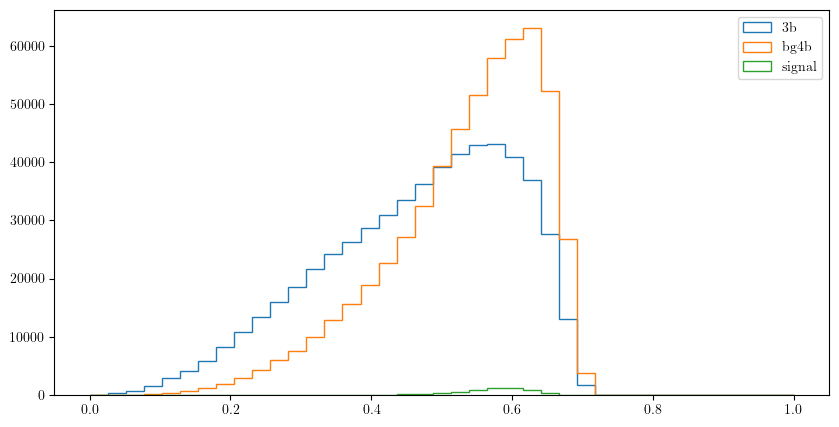

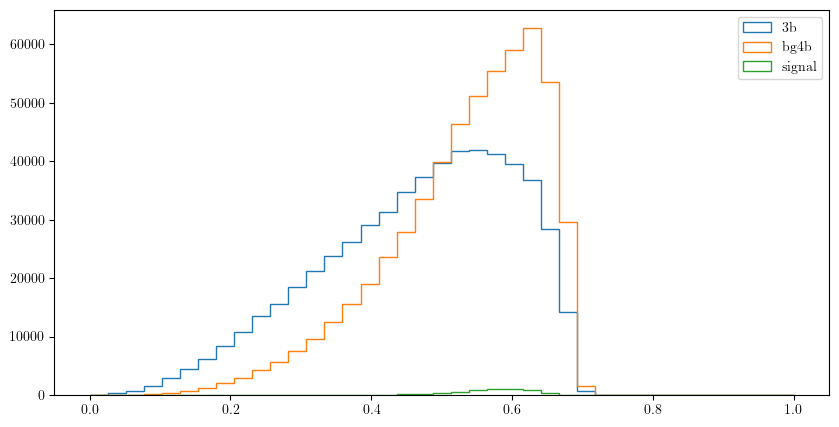

In [8]:
bins = np.linspace(0, 1, 40)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
hist_events_by_labels(events_tst, base_fvt_scores[0], bins=bins, ax=ax)
plt.legend()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
hist_events_by_labels(events_tst, base_fvt_scores_mean, bins=bins, ax=ax)
plt.legend()
plt.show()

In [10]:
hparams = TrainingInfo.get_existing_hparams()
np.unique([hp["experiment_name"] for hp in hparams])

array(['CR_fvt_training', 'CR_fvt_training_repr_norm',
       'CR_fvt_training_same_data', 'CR_fvt_training_schedulefree',
       'CR_fvt_training_schedulefree_ablation',
       'CR_fvt_training_schedulefree_ablation2', 'CR_fvt_training_v2',
       'base_fvt_training_ensemble', 'base_fvt_with_repr_norm',
       'base_fvt_with_repr_norm_smaller_repr_dim',
       'better_base_fvt_training', 'better_base_fvt_training_small',
       'smeared_fvt_training', 'smeared_fvt_training_ensemble',
       'smeared_fvt_training_noise_scale',
       'smeared_fvt_training_repr_norm', 'smeared_fvt_training_small'],
      dtype='<U40')